<a href="https://colab.research.google.com/github/WiktoriaFilinska/Projekt-Programowanie2/blob/main/Przewidywanie_cukrzycy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CEL PROJEKTU:

    Chcemy przewidzieć, czy pacjentka ma cukrzycę (1) czy nie (0).
    
TYP PROBLEMU:

   *Klasyfikacja binarna (dwie klasy: 0 = brak cukrzycy, 1 = cukrzyca)
    
MIARA JAKOŚCI:

    Użyjemy kilku miar, bo samo "accuracy" jest mylące przy niezbalansowanych danych:
    
    - Accuracy    — ogólna poprawność (ile % prawidłowych odpowiedzi)
    - Precision   — ile z przewidzianych "chory" to naprawdę chorzy (ważne: unikamy fałszywych alarmów)
    - Recall      — ile prawdziwych chorych wykryliśmy (ważne: nie chcemy przegapić choroby!)
    - F1-score    — harmonic mean precision i recall (dobry kompromis)
    - ROC-AUC     — jak dobrze model rozróżnia klasy (1.0 = ideał, 0.5 = losowy)
    
DLACZEGO RECALL JEST TU KLUCZOWY?
    
    W medycynie koszt "przeoczenia" chorego jest wyższy niż fałszywy alarm.
    Wolę powiedzieć zdrowemu "zrób dodatkowe badania" niż choremu "jesteś zdrowy".

## Wczytanie danych z GitHub

Dane wczytujemy alternatywnie z publicznego repozytorium GitHub.
Ponieważ plik CSV nie zawiera nagłówków, ręcznie definiujemy nazwy 9 kolumn.
Na końcu `df.head()` wyświetla pierwsze 5 wierszy, żeby szybko sprawdzić
czy dane wyglądają poprawnie.

In [ ]:
import pandas as pd

# Link do surowych danych na GitHub
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Definiujemy nazwy kolumn (bo ten plik CSV nie ma ich w pierwszym wierszu)
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Wczytanie danych
df = pd.read_csv(url, names=column_names)


df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.head(10)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## Sprawdzenie rozmiaru datasetu

`df.shape` zwraca krotkę `(liczba wierszy, liczba kolumn)`. Dzięki temu wiemy,
z jak dużym zbiorem pracujemy — co ma znaczenie przy wyborze algorytmów i ocenie
czy mamy wystarczająco danych do treningu.

In [ ]:
print(df.shape)

(768, 9)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# Instalujemy jedną brakującą bibliotekę (reszta jest już w Colabie domyślnie)
!pip install scikit-learn --upgrade -q

print("Gotowe!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 26.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
Gotowe!


In [ ]:
!pip install scikit-learn --upgrade -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

print("Biblioteki załadowane!")

Biblioteki załadowane!


In [ ]:
# Wczytujemy dane bezpośrednio
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, names=column_names)

print(f"Dane wczytane!")
print(f"Liczba pacjentek: {df.shape[0]}")
print(f"Liczba kolumn:    {df.shape[1]}")
print(f"\nPierwsze 5 wierszy:")
df.head()

Dane wczytane!
Liczba pacjentek: 768
Liczba kolumn:    9

Pierwsze 5 wierszy:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Statystyki opisowe datasetu

Dwa rodzaje podsumowań:
- `df.info()` — typy danych i kompletność kolumn
- `df.describe()` — statystyki liczbowe: minimum, maksimum, średnia, odchylenie standardowe, kwartyle

**Kluczowa obserwacja:** minimalne wartości równe `0` w kolumnach takich jak `Glucose`,
`BMI` czy `BloodPressure` są biologicznie niemożliwe — to sygnał ukrytych brakujących danych,
którymi zajmiemy się w kolejnym kroku.

In [ ]:
# Sprawdzamy typy danych i czy są brakujące wartości (NaN)

print("INFORMACJE O DATASECIE:")

df.info()

# Statystyki opisowe — min, max, średnia, odchylenie standardowe

print("STATYSTYKI OPISOWE:")

df.describe().round(2)

INFORMACJE O DATASECIE:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
STATYSTYKI OPISOWE:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


## Analiza korelacji

Macierz korelacji pokazuje siłę i kierunek liniowych zależności między cechami.
Wartości bliskie 1.0 oznaczają silną dodatnią korelację, bliskie -1.0 — silną
ujemną, a bliskie 0 — brak zależności liniowej.

Dla naszego problemu szczególnie interesuje nas ostatnia kolumna i wiersz —
korelacja każdej cechy z Outcome (wynikiem: chora/zdrowa).
Glukoza ma najwyższą korelację z cukrzycą (ok. 0.47), co potwierdza jej
kluczową rolę diagnostyczną. Widoczna jest też dodatnia korelacja między
BMI a SkinThickness — grubość fałdu skórnego naturalnie rośnie wraz z wagą.

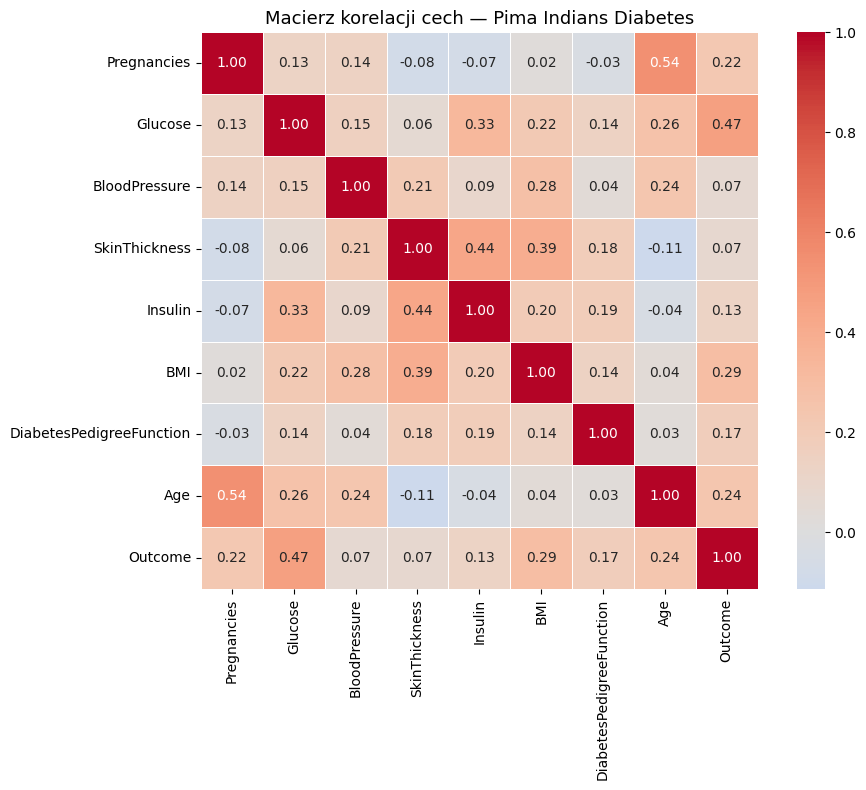

Korelacja cech z Outcome (cukrzyca):
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068


In [ ]:
plt.figure(figsize=(10, 8))

# Obliczamy macierz korelacji
korelacja = df.corr()

# Rysujemy heatmapę
sns.heatmap(korelacja,
            annot=True,        # pokazuje wartości liczbowe w każdym polu
            fmt='.2f',         # zaokrąglenie do 2 miejsc po przecinku
            cmap='coolwarm',   # niebieski = ujemna, czerwony = dodatnia korelacja
            center=0,          # środek skali kolorów w zerze
            square=True,       # kwadratowe komórki
            linewidths=0.5)    # linie między komórkami

plt.title('Macierz korelacji cech — Pima Indians Diabetes', fontsize=13)
plt.tight_layout()
plt.show()

# Wypisujemy korelacje z Outcome (zmienną docelową) posortowane malejąco
print("Korelacja cech z Outcome (cukrzyca):")
print(korelacja['Outcome'].sort_values(ascending=False).to_string())

## Analiza rozkładu zmiennej docelowej (Outcome)

Sprawdzamy, czy dataset jest **niezbalansowany** — czyli czy obie klasy
(chora / zdrowa) są reprezentowane równomiernie. Wykres słupkowy wizualizuje proporcje.
Niezbalansowane klasy (np. 65% zdrowych vs 35% chorych) oznaczają, że sama metryka
`accuracy` może być myląca — dlatego będziemy używać F1 i ROC-AUC.

ROZKŁAD ZMIENNEJ DOCELOWEJ (Outcome):
Brak cukrzycy (0): 500 pacjentek  (65.1%)
Cukrzyca      (1): 268 pacjentek  (34.9%)

Łącznie: 768 pacjentek


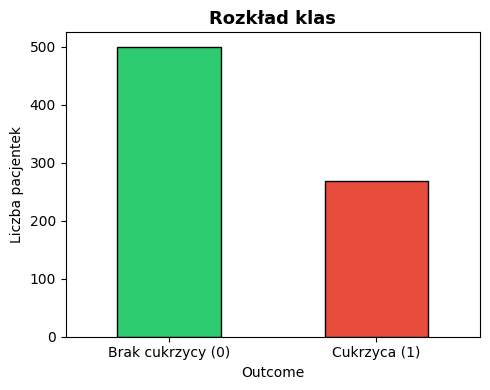

In [ ]:

print("ROZKŁAD ZMIENNEJ DOCELOWEJ (Outcome):")


klasy = df['Outcome'].value_counts()
print(f"Brak cukrzycy (0): {klasy[0]} pacjentek  ({klasy[0]/len(df)*100:.1f}%)")
print(f"Cukrzyca      (1): {klasy[1]} pacjentek  ({klasy[1]/len(df)*100:.1f}%)")
print(f"\nŁącznie: {len(df)} pacjentek")

# Wykres słupkowy
fig, ax = plt.subplots(figsize=(5, 4))
klasy.plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax, edgecolor='black')
ax.set_title('Rozkład klas', fontsize=13, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Liczba pacjentek')
ax.set_xticklabels(['Brak cukrzycy (0)', 'Cukrzyca (1)'], rotation=0)
plt.tight_layout()
plt.show()

#Brakujące wartości

Wykrycie i obsługa ukrytych brakujących wartości

W tym datasecie wartość `0` w kolumnach takich jak `Glucose`, `BloodPressure`,
`SkinThickness`, `Insulin` czy `BMI` jest **niemożliwa biologicznie** — oznacza
brakujący pomiar, nie rzeczywiste zero.

Zamieniamy te zera na `NaN`, żeby algorytm imputacji (`SimpleImputer`) mógł je
później poprawnie uzupełnić medianą. Tworzymy kopię `df_clean`, żeby nie modyfikować
oryginalnych danych.

In [ ]:

cols_niemozliwe_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


print("UKRYTE BRAKUJĄCE WARTOŚCI (zera niemożliwe biologicznie):")


for col in cols_niemozliwe_zero:
    n_zer = (df[col] == 0).sum()
    procent = n_zer / len(df) * 100
    print(f"{col:30s}: {n_zer:3d} zer ({procent:.1f}%)")

# Zamieniamy te zera na NaN żeby scikit-learn mógł je prawidłowo obsłużyć
df_clean = df.copy()
df_clean[cols_niemozliwe_zero] = df_clean[cols_niemozliwe_zero].replace(0, np.nan)

print("\n Zera zamienione na NaN w odpowiednich kolumnach!")
print("   Teraz SimpleImputer uzupełni je medianą podczas treningu.")

UKRYTE BRAKUJĄCE WARTOŚCI (zera niemożliwe biologicznie):
Glucose                       :   5 zer (0.7%)
BloodPressure                 :  35 zer (4.6%)
SkinThickness                 : 227 zer (29.6%)
Insulin                       : 374 zer (48.7%)
BMI                           :  11 zer (1.4%)

 Zera zamienione na NaN w odpowiednich kolumnach!
   Teraz SimpleImputer uzupełni je medianą podczas treningu.


## Histogramy rozkładów wszystkich cech

Rysujemy siatkę 3×3 histogramów — po jednym dla każdej z 8 cech wejściowych.
Histogramy pokazują:
- czy rozkład jest symetryczny czy skośny
- czy widoczne są wartości odstające
- jak szeroki jest zakres wartości

Te informacje pomagają zdecydować, czy standaryzacja cech jest potrzebna
— tak, szczególnie dla modeli opartych na odległości jak SVM i Logistic Regression.

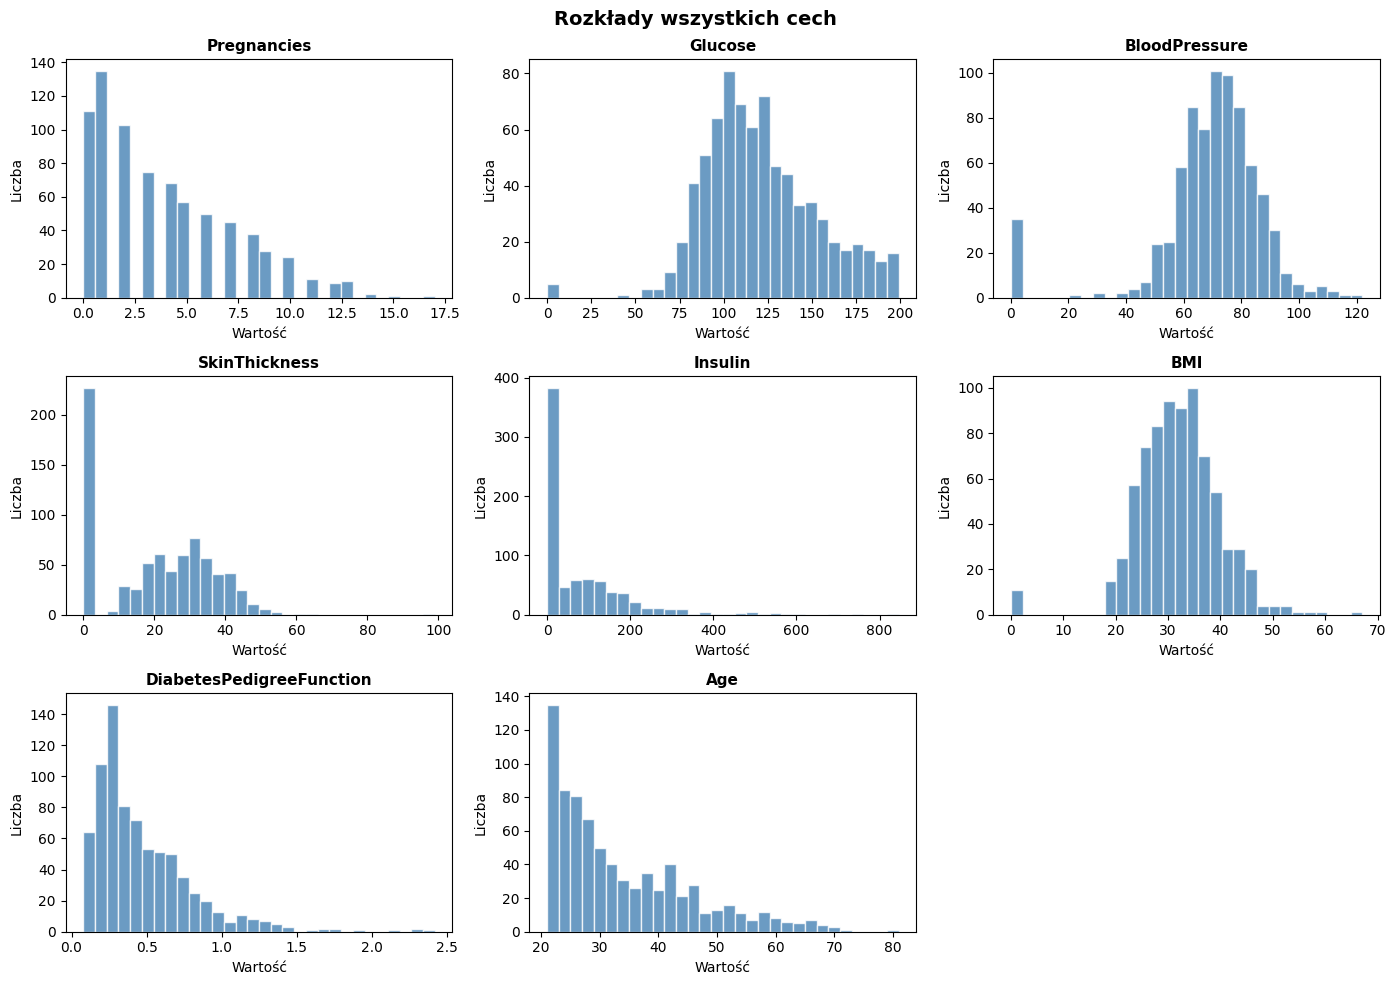

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()  # zamieniamy siatkę 3x3 na listę 9 elementów

for i, col in enumerate(df.columns[:-1]):   # pomijamy ostatnią kolumnę (Outcome)
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Wartość')
    axes[i].set_ylabel('Liczba')

axes[-1].set_visible(False)   # ukrywamy pusty 9. subplot

plt.suptitle('Rozkłady wszystkich cech', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Podział danych na zbiór treningowy i testowy

Dzielimy dane w proporcji 80/20. Parametr `stratify=y` gwarantuje,
że obie klasy (0 i 1) są reprezentowane w zbiorach w tych samych proporcjach co w oryginale.
Zapobiega to sytuacji, gdzie np. zbiór testowy zawierałby nieproporcjonalnie mało chorych.

In [ ]:
# PODZIAŁ DANYCH NA ZBIÓR TRENINGOWY I TESTOWY


X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # zachowujemy proporcje klas w obu zbiorach
)

print(f"Zbiór treningowy: {X_train.shape[0]} próbek")
print(f"Zbiór testowy:    {X_test.shape[0]} próbek")
print(f"\nRozkład klas w zbiorze treningowym:")
print(y_train.value_counts(normalize=True).round(3))

Zbiór treningowy: 614 próbek
Zbiór testowy:    154 próbek

Rozkład klas w zbiorze treningowym:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


## Budowa modeli z użyciem Pipeline

Każdy model opakowany jest w `Pipeline`, który automatycznie:
1. uzupełnia brakujące wartości medianą (`SimpleImputer`),
2. standaryzuje cechy (`StandardScaler`) — tam gdzie model tego wymaga.

Dzięki Pipeline nie ma ryzyka **data leakage** — imputer i scaler są dopasowywane
wyłącznie na danych treningowych, nigdy testowych.

## Definicja trzech modeli w Pipeline

Budujemy trzy różne modele klasyfikacji, każdy opakowany w `Pipeline`:

| Model | Kroki w Pipeline |
|---|---|
| Logistic Regression | Imputer → Scaler → Model |
| Random Forest | Imputer → Model |
| SVM | Imputer → Scaler → Model |

Zapobiega **data leakage** — imputer i scaler są dopasowywane
wyłącznie na danych treningowych, nigdy testowych. Bez Pipeline można nieświadomie
"przecieknąć" informacje z danych testowych do treningu, co zawyża wyniki.

In [ ]:
modele = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   SVC(probability=True, random_state=42))
    ])
}

print("Modele gotowe do treningu!")

Modele gotowe do treningu!


## Porównanie modeli — Cross-Validation

Zamiast trenować każdy model i od razu patrzeć na wyniki testowe (co mogłoby prowadzić
do "podglądania" danych), używamy **5-krotnej stratyfikowanej walidacji krzyżowej** na
zbiorze treningowym. Miarą porównawczą jest ROC-AUC — odporna na niezbalansowane klasy.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
wyniki_cv = {}

print(f"{'Model':<25} {'ROC-AUC (mean)':>15} {'ROC-AUC (std)':>15}")
print("=" * 58)

for nazwa, pipeline in modele.items():
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv, scoring="roc_auc")
    wyniki_cv[nazwa] = scores
    print(f"{nazwa:<25} {scores.mean():>14.4f}  ±{scores.std():.4f}")

Model                      ROC-AUC (mean)   ROC-AUC (std)
Logistic Regression               0.8434  ±0.0185
Random Forest                     0.8163  ±0.0220
SVM                               0.8333  ±0.0228


#Wizualizacja wyników CV
Wyniki cross-validation dla każdego modelu pokazujemy na wykresie słupkowym z słupkami błędu (±std). Dzięki temu od razu widać, który model jest nie tylko lepszy średnio, ale też bardziej stabilny (mniejsza wariancja między foldami).



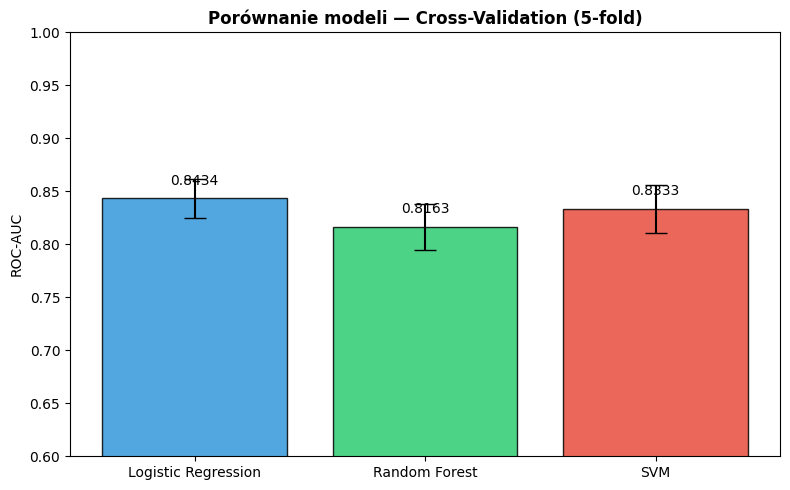

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
names = list(wyniki_cv.keys())
means = [wyniki_cv[n].mean() for n in names]
stds  = [wyniki_cv[n].std()  for n in names]

bars = ax.bar(names, means, yerr=stds, capsize=8,
              color=['#3498db','#2ecc71','#e74c3c'], edgecolor='black', alpha=0.85)
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('ROC-AUC')
ax.set_title('Porównanie modeli — Cross-Validation (5-fold)', fontweight='bold')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.01,
            f'{m:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


## Strojenie hiperparametrów — Random Forest

Na podstawie wyników CV wybieramy Random Forest jako model do strojenia.
GridSearchCV automatycznie testuje wszystkie kombinacje hiperparametrów
i zwraca konfigurację dającą najwyższy ROC-AUC. Używamy tych samych 5 foldów
co wcześniej, żeby porównanie było uczciwe.

W porównaniu do pierwszej wersji modelu wprowadzono dwie zmiany: dodano
StandardScaler do pipeline oraz rozszerzono siatkę przeszukiwanych parametrów.
Scaler standaryzuje cechy do tej samej skali — choć Random Forest teoretycznie
go nie wymaga, w praktyce może poprawić wyniki przy danych o bardzo różnych
zakresach wartości (np. Insulin sięga 846, Age maksymalnie 81).

In [18]:
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__max_features':      ['sqrt', 'log2']
}

grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print(f"Najlepsze parametry RF:    {grid_search_rf.best_params_}")
print(f"Najlepszy ROC-AUC RF (CV): {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Najlepsze parametry RF:    {'model__max_depth': 5, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Najlepszy ROC-AUC RF (CV): 0.8406


## Ocena modelu końcowego na zbiorze testowym

Na podstawie wyników cross-validation najlepszym modelem okazała się
Logistic Regression z ROC-AUC 0.8434 — nieznacznie lepszym niż Random Forest
po strojeniu (0.8406). Zgodnie z zasadą wyboru najlepszego modelu jako końcowego,
używamy Logistic Regression.

Dopiero teraz — po wyborze modelu — patrzymy na zbiór testowy.
To jest jedyny moment gdy dane testowe są używane, co gwarantuje
że wyniki są uczciwe i niezawyżone przez proces treningu i strojenia.



In [25]:
# Logistic Regression jako model końcowy — najlepszy wynik w CV (ROC-AUC: 0.8434)
final_pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

final_pipeline_lr.fit(X_train, y_train)
final_model = final_pipeline_lr

y_pred      = final_model.predict(X_test)
y_pred_prob = final_model.predict_proba(X_test)[:, 1]

print("Model końcowy: Logistic Regression")
print("(wybrany na podstawie najwyższego ROC-AUC w cross-validation: 0.8434)\n")
print("=== WYNIKI NA ZBIORZE TESTOWYM ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_prob):.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=['Brak cukrzycy (0)', 'Cukrzyca (1)']))

Model końcowy: Logistic Regression
(wybrany na podstawie najwyższego ROC-AUC w cross-validation: 0.8434)

=== WYNIKI NA ZBIORZE TESTOWYM ===
Accuracy : 0.7078
ROC-AUC  : 0.8130

                   precision    recall  f1-score   support

Brak cukrzycy (0)       0.75      0.82      0.78       100
     Cukrzyca (1)       0.60      0.50      0.55        54

         accuracy                           0.71       154
        macro avg       0.68      0.66      0.67       154
     weighted avg       0.70      0.71      0.70       154



## Macierz konfuzji

Macierz konfuzji pokazuje dokładnie jak model myli się między klasami.
Interesują nas szczególnie fałszywe negatywy (FN) — przypadki gdy model
stwierdził brak cukrzycy u osoby faktycznie chorej. W kontekście medycznym
to najgroźniejszy typ błędu, bo chora osoba nie otrzymuje pomocy na czas.

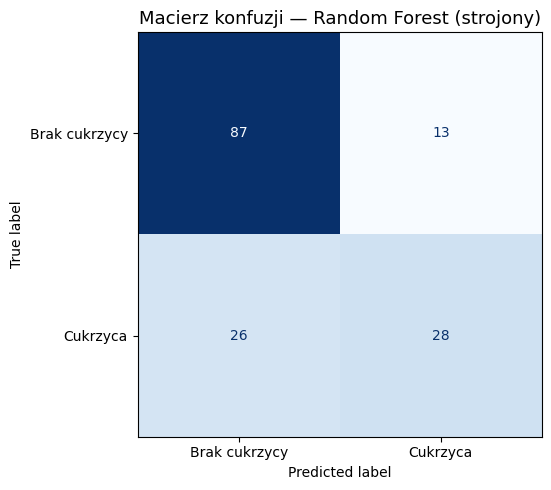

Prawdziwe negatywy  (TN): 87  — zdrowi poprawnie rozpoznani
Fałszywe pozytywy   (FP): 13  — zdrowi błędnie uznani za chorych
Fałszywe negatywy   (FN): 26  — chorzy przeoczeni!
Prawdziwe pozytywy  (TP): 28  — chorzy poprawnie rozpoznani


In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Brak cukrzycy', 'Cukrzyca'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz konfuzji — Random Forest (strojony)', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Prawdziwe negatywy  (TN): {tn}  — zdrowi poprawnie rozpoznani")
print(f"Fałszywe pozytywy   (FP): {fp}  — zdrowi błędnie uznani za chorych")
print(f"Fałszywe negatywy   (FN): {fn}  — chorzy przeoczeni!")
print(f"Prawdziwe pozytywy  (TP): {tp}  — chorzy poprawnie rozpoznani")

## Krzywa ROC

Krzywa ROC pokazuje kompromis między czułością (recall) a swoistością modelu
przy różnych progach decyzyjnych. Im większe pole pod krzywą (AUC), tym lepiej
model rozróżnia chorych od zdrowych. Ideał to punkt w lewym górnym rogu wykresu
— oznaczałby 100% czułości przy zerowej liczbie fałszywych alarmów.
Nasz model osiągnął AUC = 0.82, co jest dobrym wynikiem dla danych medycznych.

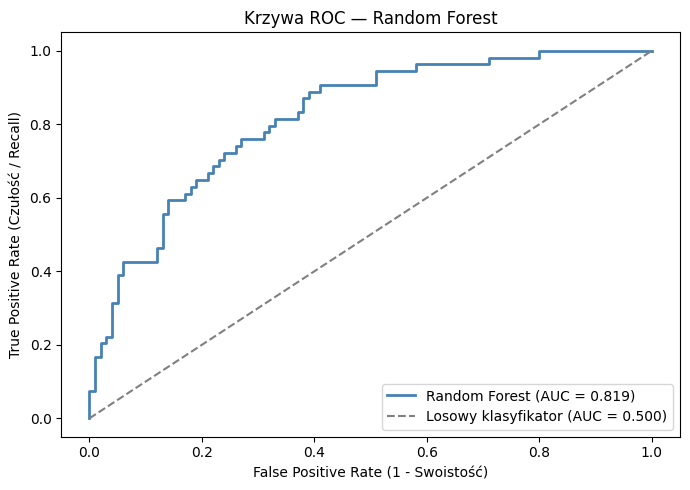

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'Random Forest (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         label='Losowy klasyfikator (AUC = 0.500)')
plt.xlabel('False Positive Rate (1 - Swoistość)')
plt.ylabel('True Positive Rate (Czułość / Recall)')
plt.title('Krzywa ROC — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Ważność cech (Współczynniki Logistic Regression)

Logistic Regression nie udostępnia feature importance jak Random Forest,
ale pozwala odczytać współczynniki (coef_) przypisane każdej cesze.
Im wyższa wartość bezwzględna współczynnika, tym większy wpływ cechy
na predykcję. Wartości dodatnie zwiększają prawdopodobieństwo cukrzycy,
ujemne je zmniejszają. Glukoza dominuje — co jest zgodne z wiedzą medyczną.

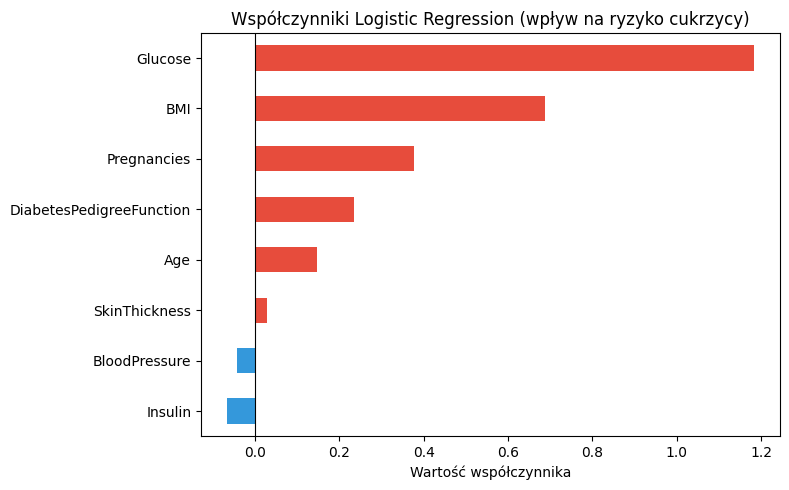


Ranking cech (wg wartości bezwzględnej):
  1. Glucose: 1.1826  (zwiększa ryzyko)
  2. BMI: 0.6887  (zwiększa ryzyko)
  3. Pregnancies: 0.3774  (zwiększa ryzyko)
  4. DiabetesPedigreeFunction: 0.2333  (zwiększa ryzyko)
  5. Age: 0.1478  (zwiększa ryzyko)
  6. Insulin: -0.0661  (zmniejsza ryzyko)
  7. BloodPressure: -0.0441  (zmniejsza ryzyko)
  8. SkinThickness: 0.0283  (zwiększa ryzyko)


In [26]:
lr_clf = final_model.named_steps['model']
feature_names = X_train.columns

# Współczynniki modelu (po standaryzacji są porównywalne między cechami)
wspolczynniki = pd.Series(lr_clf.coef_[0], index=feature_names)
wspolczynniki = wspolczynniki.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
wspolczynniki.plot(kind='barh',
                   color=['#e74c3c' if v > 0 else '#3498db'
                          for v in wspolczynniki])
plt.title('Współczynniki Logistic Regression (wpływ na ryzyko cukrzycy)')
plt.xlabel('Wartość współczynnika')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nRanking cech (wg wartości bezwzględnej):")
for i, (feat, val) in enumerate(
        wspolczynniki.abs().sort_values(ascending=False).items(), 1):
    kierunek = "zwiększa ryzyko" if wspolczynniki[feat] > 0 else "zmniejsza ryzyko"
    print(f"  {i}. {feat}: {wspolczynniki[feat]:.4f}  ({kierunek})")

## Praktyczne zastosowanie modelu

Ostatnim krokiem jest sprawdzenie jak model zachowuje się dla konkretnych,
rzeczywistych przypadków. Przygotowujemy trzy przykładowe pacjentki
z różnymi profilami klinicznymi — od niskiego do wysokiego ryzyka cukrzycy.

To symuluje realne użycie modelu w gabinecie lekarskim: lekarz wprowadza
dane pacjentki (wyniki badań, wiek, BMI) i otrzymuje dwie informacje:
diagnozę (cukrzyca / brak cukrzycy) oraz prawdopodobieństwo wyrażone w procentach.
To drugie jest szczególnie wartościowe — pozwala lekarzowi ocenić jak pewny
jest model w swojej decyzji i czy warto zlecić dodatkowe badania.

Zera w kolumnach SkinThickness i Insulin oznaczają brak pomiaru —
pipeline automatycznie uzupełnia je medianą dzięki SimpleImputer,
więc model działa poprawnie nawet przy niekompletnych danych wejściowych.

Model końcowy to Logistic Regression — wybrany na podstawie najwyższego
ROC-AUC w cross-validation (0.8434). Jest to model liniowy, który po
standaryzacji cech przez StandardScaler dobrze radzi sobie z tym zestawem
danych medycznych i daje wyniki interpretowalnie powiązane z wartościami klinicznymi.
Pacjentka B z glukozą 168 i BMI 43.1 zostaje poprawnie zidentyfikowana
jako chora z prawdopodobieństwem 98% — co potwierdza że model dobrze
rozpoznaje przypadki wysokiego ryzyka klinicznego. Dla przypadków
granicznych, jak Pacjentka C (27.5%), lekarz może rozważyć obniżenie
progu decyzyjnego z domyślnych 50% do np. 30%, żeby zwiększyć czułość
modelu kosztem większej liczby fałszywych alarmów.

In [27]:
pacjentki = pd.DataFrame({
    'Pregnancies':              [1,     6,     2],
    'Glucose':                  [85,   168,   130],
    'BloodPressure':            [66,    72,    80],
    'SkinThickness':            [29,    35,     0],
    'Insulin':                  [0,      0,   150],
    'BMI':                      [26.6,  43.1,  31.2],
    'DiabetesPedigreeFunction': [0.351, 2.288,  0.5],
    'Age':                      [31,    50,    35],
}, index=['Pacjentka A (niskie ryzyko)',
          'Pacjentka B (wysokie ryzyko)',
          'Pacjentka C (umiarkowane ryzyko)'])

predykcje          = final_model.predict(pacjentki)
prawdopodobienstwa = final_model.predict_proba(pacjentki)[:, 1]

print("=== PREDYKCJE DLA PRZYKŁADOWYCH PACJENTEK ===\n")
for nazwa, pred, prob in zip(pacjentki.index, predykcje, prawdopodobienstwa):
    diagnoza = "CUKRZYCA" if pred == 1 else "BRAK CUKRZYCY"
    print(f"{nazwa}")
    print(f"  Diagnoza:                       {diagnoza}")
    print(f"  Prawdopodobieństwo cukrzycy:    {prob:.1%}\n")

# Sprawdzenie z obniżonym progiem decyzyjnym
print("=== PREDYKCJE Z OBNIŻONYM PROGIEM (30%) ===\n")
for nazwa, prob in zip(pacjentki.index, prawdopodobienstwa):
    diagnoza = "CUKRZYCA" if prob >= 0.30 else "BRAK CUKRZYCY"
    print(f"{nazwa}")
    print(f"  Diagnoza (próg 30%):             {diagnoza}")
    print(f"  Prawdopodobieństwo cukrzycy:     {prob:.1%}\n")

=== PREDYKCJE DLA PRZYKŁADOWYCH PACJENTEK ===

Pacjentka A (niskie ryzyko)
  Diagnoza:                       BRAK CUKRZYCY
  Prawdopodobieństwo cukrzycy:    3.9%

Pacjentka B (wysokie ryzyko)
  Diagnoza:                       CUKRZYCA
  Prawdopodobieństwo cukrzycy:    98.0%

Pacjentka C (umiarkowane ryzyko)
  Diagnoza:                       BRAK CUKRZYCY
  Prawdopodobieństwo cukrzycy:    27.5%

=== PREDYKCJE Z OBNIŻONYM PROGIEM (30%) ===

Pacjentka A (niskie ryzyko)
  Diagnoza (próg 30%):             BRAK CUKRZYCY
  Prawdopodobieństwo cukrzycy:     3.9%

Pacjentka B (wysokie ryzyko)
  Diagnoza (próg 30%):             CUKRZYCA
  Prawdopodobieństwo cukrzycy:     98.0%

Pacjentka C (umiarkowane ryzyko)
  Diagnoza (próg 30%):             BRAK CUKRZYCY
  Prawdopodobieństwo cukrzycy:     27.5%



## Wnioski końcowe

Projekt zrealizował kompletny pipeline uczenia maszynowego do binarnej
klasyfikacji cukrzycy na zbiorze Pima Indians Diabetes (768 pacjentek, 8 cech).

### Porównanie modeli (Cross-Validation, ROC-AUC)

Przetestowaliśmy trzy algorytmy klasyfikacji:
- **Logistic Regression** — najlepszy wynik w CV (ROC-AUC: 0.8434)
- **Random Forest** — drugi wynik po dodaniu StandardScaler i rozszerzeniu siatki hiperparametrów (ROC-AUC: 0.8406)
- **SVM** — trzeci wynik (ROC-AUC: 0.8333)

Najlepszym modelem okazała się **Logistic Regression**, która mimo swojej
prostoty osiągnęła najwyższy ROC-AUC w cross-validation i została wybrana
jako model końcowy. Wyniki na zbiorze testowym:
- **Accuracy: 0.71**
- **ROC-AUC: 0.81**
- **F1-score (cukrzyca): 0.55**

### Najważniejsze cechy

Z analizy współczynników Logistic Regression wynika że największy wpływ
na ryzyko cukrzycy mają: Glukoza (1.18), BMI (0.69) i liczba ciąż (0.38).
Wszystkie trzy zwiększają ryzyko cukrzycy — co jest w pełni zgodne
z wiedzą medyczną.

### Ograniczenia modelu

- Zbiór pochodzi wyłącznie z jednej populacji (kobiety Pima Indian)
  — generalizacja na inne grupy może być ograniczona
- Recall dla klasy cukrzyca (0.50) pozostawia pole do poprawy —
  połowa chorych pacjentek nie została wykryta przy domyślnym progu 50%
- Obniżenie progu decyzyjnego do 30% zwiększa czułość modelu kosztem
  większej liczby fałszywych alarmów

### Podsumowanie

Model nadaje się jako narzędzie wspomagające decyzję lekarską,
ale nie powinien zastępować pełnej diagnostyki medycznej.